# Burgers equation

The Burgers equation is a fundamental nonlinear partial differential equation that plays a central role in fluid dynamics, nonlinear wave propagation, and traffic flow modeling. Despite its apparent simplicity, it exhibits rich behavior such as shock formation and nonlinear transport, making it a standard benchmark for testing numerical methods.

In one spatial dimension, the viscous Burgers equation reads
$$\partial_t u + u \, \partial_x u = \nu \, \partial_{xx} u,$$

where $u(x,t)$ is the scalar velocity field and $\nu \ge 0$ is the viscosity coefficient. In the inviscid limit $\nu \to 0$, the equation develops discontinuities in finite time, while for $\nu > 0$ diffusion regularizes the solution.

In this notebook, we solve the Burgers equation using **Discrete Exterior Calculus (DEC)**. The goal is to demonstrate how DEC can be used to solve nonlinear conservation laws while maintaining geometric consistency, and to compare its behavior with more traditional finite difference–based discretizations.

## Imports and reference solution on a fine grid

We first import the required packages and define a fine space–time grid, which is used to compute a high-resolution reference solution of the one-dimensional viscous Burgers equation in conservative form
$$
\partial_t u + \partial_x\!\left(\frac{u^2}{2}\right) = \nu\,\partial_{xx} u .
$$

The spatial domain $x \in [0,L]$ is discretized with spacing $\Delta x$, and time is discretized with step size $\Delta t$. The convective term is approximated using a centered finite difference of the flux,
$$
\left(\partial_x \frac{u^2}{2}\right)_i^n
\approx
\frac{(u_{i+1}^n)^2 - (u_{i-1}^n)^2}{4\Delta x},
$$
while the diffusive term is discretized as
$$
(\partial_{xx} u)_i^n \approx
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

Time integration is performed using an explicit Euler scheme,
$$u_i^{n+1}=u_i^n-\Delta t \left(\partial_x \frac{u^2}{2}\right)_i^n+\nu\,\Delta t\,(\partial_{xx} u)_i^n .$$

This fine-grid finite difference solution is used as a reference for comparison with the DEC-based discretizations introduced later.


In [1]:
import dctkit as dt_
from dctkit import config
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from dctkit.mesh.simplex import SimplicialComplex
from dctkit.mesh import util
from dctkit.dec import cochain as C
from dctkit.dec.flat import flat_DPD as flat_par
from dctkit.dec.flat import flat_dual_upw as flat_upw
from matplotlib import cm
import pygmo as pg
import math
from jax import jit,lax
import time
import jax.numpy as jnp
from functools import partial

In [2]:
config()

In [3]:
# SPACE PARAMS
# spatial resolution
dx = 2**4/2**9
L = 2**4 + dx
#  Number of spatial grid points
nx = int(math.ceil(L / dx))

# vector containing spatial points
x = np.linspace(-L/2, L/2, nx)
# circumcenters
x_circ = (x[:-1] + x[1:])/2


# initial velocity
u_0 = np.exp(-1 * (x_circ + 0.5 * L/4)**2)
umax = np.max(u_0)
x_max = np.argmax(u_0)

In [4]:
# TIME PARAMS
T = 10
# temporal resolution
dt = 10/2**11
# number of temporal grid points
nt = int(math.ceil(T / dt))

# vector containing time points
t = np.linspace(0, T, nt)  

#Viscosity
nu = 0.005

nodes_BC = {'left': np.zeros(nt),
            'right': np.zeros(nt)}

In [5]:
def main_run_FDM(u,x, dt, dx, nu, max_time_iter):
    for t in range(max_time_iter):
        u[1:-1, t+1] = u[1:-1, t] + dt * (nu * (u[2:, t] - 2 * u[1:-1, t] + u[:-2, t]) / dx**2 
                   - 0.25 * (u[2:, t]**2 - u[:-2, t]**2) / dx)
    return u

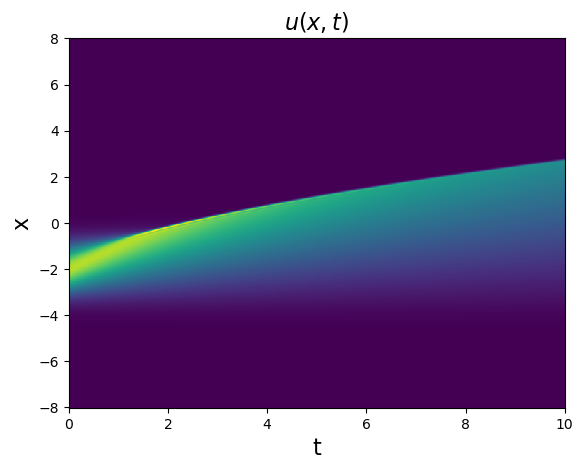

In [6]:
# Array containing velocity
u = np.zeros([nx-1, nt]) 

# Initial condition
u[:, 0] = u_0
# Boundary condition at x=0
u[0, :] = 0
# Boundary condition at x=xmax
u[-1, :] = 0 

u = main_run_FDM(u, x,dt, dx, nu, nt-1)


plt.pcolormesh(t,x_circ,u)
plt.xlabel('t', fontsize=16)
plt.ylabel('x', fontsize=16)
plt.title(r'$u(x, t)$', fontsize=16)
plt.show()

## DEC for Burgers with parabolic and upwind method

We now discretize the Burgers equation using **Discrete Exterior Calculus (DEC)** on a one-dimensional simplicial mesh. The scalar field $u(x,t)$ is represented as a dual 0-cochain, while fluxes are represented as primal 1-cochains. The discrete exterior derivative $d$ and the Hodge star $\star$ are used to construct discrete differential operators.

The nonlinear convective flux is evaluated using two different DEC-based closures:
- **Parabolic flux**, equivalent to the finite difference method, yielding a centered (second-order) discretization.
- **Upwind flux**, improving stability in advection-dominated regimes.

Time integration is performed using an explicit scheme, and the resulting DEC solutions are compared against the fine-grid finite difference reference.

In [7]:
# define simplicial complex
mesh, _ = util.generate_line_mesh(nx, L, x_min=-L/2)
S = util.build_complex_from_mesh(mesh, space_dim=1)
S.get_hodge_star()
S.get_flat_DPD_weights()
S.get_flat_dual_upw_weights()

In [8]:
def compute_time_balance(u_t, nu, scheme: str = "parabolic"):
        u_coch = C.CochainD0(S, u_t)
        dissipation = C.scalar_mul(C.star(C.coboundary(u_coch)), nu)
        if scheme == "upwind":
            flat_u = flat_upw(u_coch)
            flux = C.scalar_mul(C.square(C.star(flat_u)), -1/2)
        elif scheme == "parabolic":
            u_sq = C.scalar_mul(C.square(u_coch), -1/2)
            flux = C.star(flat_par(u_sq))
        total_flux = C.add(flux, dissipation)
        balance = C.star(C.coboundary(total_flux))
        return balance


def run(u_0, nodes_BC, num_t_points, nu, step, scheme: str = "parabolic"):
        """Main run to solve Burgers' equation with DEC.

        Args:
            scheme: discretization scheme used.
        """
        u = np.zeros((S.num_nodes - 1, num_t_points//step),
                          dtype=dt_.float_dtype)
        # set initial and boundary conditions
        u[:, 0] = u_0
        u[0, :] = nodes_BC['left'][::step]
        u[-1, :] = nodes_BC['right'][::step]
        #NOTE: this for loop can easily be optimized with jax.lax.scan
        # but we decided to keep it simple for the introductory purpose
        # of the notebook
        for t in range(num_t_points//step - 1):
            u_t = u[:, t]
            balance = compute_time_balance(u_t, nu, scheme)
            u[1:-1, t+1] = u[1:-1, t] + step*dt*balance.coeffs[1:-1].flatten()
        return u

In [9]:
u_dec_par = run(u_0, nodes_BC, nt, nu, 4, "parabolic")
u_dec_upw = run(u_0, nodes_BC, nt, nu, 4, "upwind")

## Plots

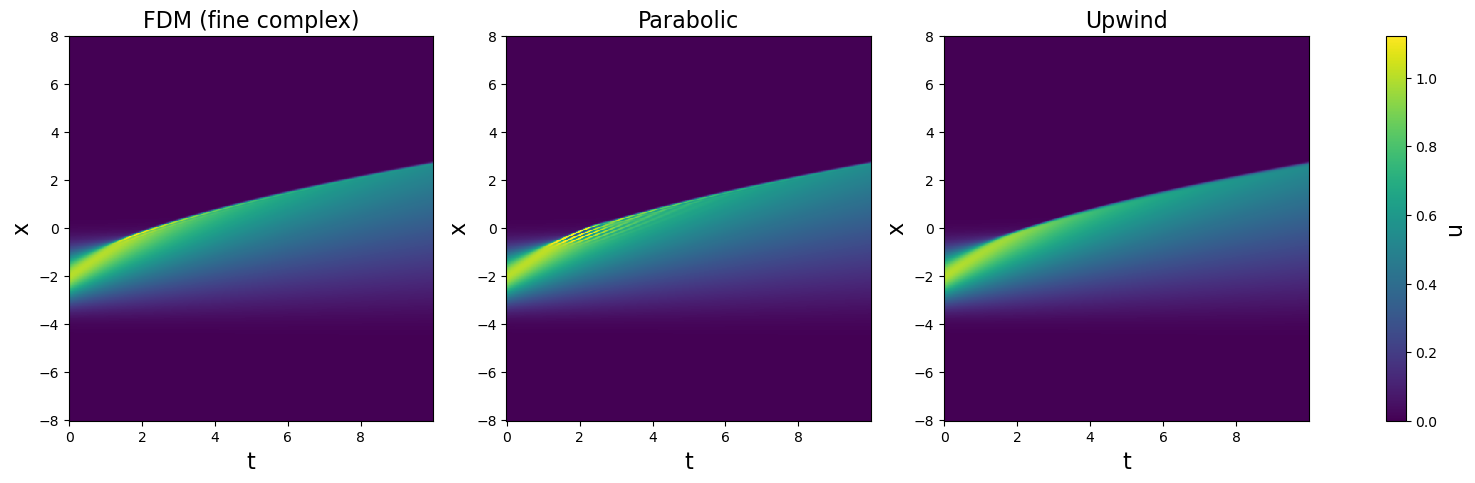

In [10]:
fig1, ax = plt.subplots(1, 3, figsize=(20, 5))

# First plot (FDM) — keep the returned mappable
pcm = ax[0].pcolormesh(
    t[::4], x_circ, u[:, ::4],
    shading="auto"
)

# Use the same norm and cmap for the other plots
ax[1].pcolormesh(
    t[::4], x_circ, u_dec_par,
    shading="auto",
    cmap=pcm.cmap,
    norm=pcm.norm
)

ax[2].pcolormesh(
    t[::4], x_circ, u_dec_upw,
    shading="auto",
    cmap=pcm.cmap,
    norm=pcm.norm
)

for i in range(3):
    ax[i].set_xlabel('t', fontsize=16)
    ax[i].set_ylabel('x', fontsize=16)

ax[0].set_title(r'FDM (fine complex)', fontsize=16)
ax[1].set_title(r'Parabolic', fontsize=16)
ax[2].set_title(r'Upwind', fontsize=16)

# One shared colorbar, driven by the FDM plot
cbar = fig1.colorbar(pcm, ax=ax, orientation='vertical')
cbar.set_label('u', fontsize=16)
plt.show()

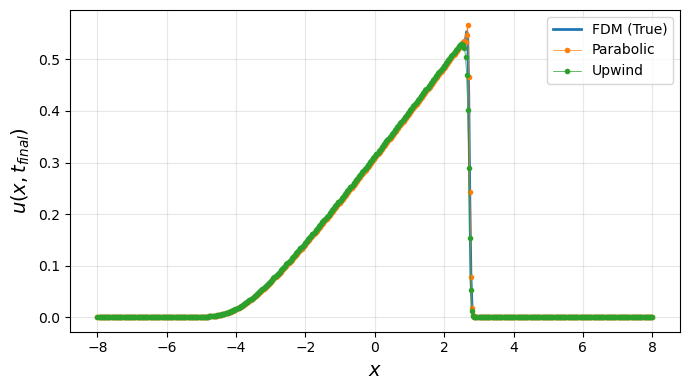

In [11]:
plt.figure(figsize=(7, 4))

# True (FDM)
plt.plot(
    x_circ,
    u[:, ::4][:, -1],
    linewidth=2,
    label="FDM (True)"
)

# Parabolic
plt.plot(
    x_circ,
    u_dec_par[:, -1],
    marker=".",
    linewidth=0.5,
    label="Parabolic"
)

# Upwind
plt.plot(
    x_circ,
    u_dec_upw[:, -1],
    marker=".",
    linewidth=0.5,
    label="Upwind"
)

plt.xlabel(r"$x$", fontsize=14)
plt.ylabel(r"$u(x, t_{final})$", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()